# De novo promoter genome scan

In [ ]:
import pandas as pd
pd.options.mode.copy_on_write = True
import numpy as np

import bson
from numba import njit

from bson import decode_all

import gffutils
import scipy

from Bio import SeqIO

import regseq2
import matplotlib.pyplot as plt

regseq2.viz.matplotlib_style()

Import results from genome scan and only keep results where mutations lead to an increase in predicted transcription rate.

In [2]:
df = pd.read_parquet('promoter_scan_summary.parquet')
df.groupby(['best_alt']).apply(len, include_groups=False)[['T', 'A']].sum() / len(df)

np.float64(0.7032038991239924)

In [3]:
np.max(df.loc[df['strand'] == '+', 'window_start'])

np.int64(4641567)

In [8]:
FASTA_PATH   = "../../data/metadata/mg1655_genome.fasta"
record = next(SeqIO.parse(FASTA_PATH, "fasta"))

df.loc[df['strand'] == '-', 'window_start'] =  len(record.seq) - df.loc[df['strand'] == '-', 'window_start']

In [9]:
df.head()

,window_start,pos_in_window,orig_base,best_alt,max_rate,wt_rate,TSS,strand
0,45,39,C,T,1333.215553,1332.952713,61,+
1,45,5,A,T,1313.667728,1332.952713,61,+
2,45,1,A,T,1313.667728,1332.952713,61,+
3,45,0,T,A,1332.952713,1332.952713,61,+
4,45,34,G,T,1332.862090,1332.952713,61,+


In [10]:
df = df[(df['max_rate'] - df['wt_rate']) > 0]
df.groupby(['best_alt']).apply(len, include_groups=False)[['T', 'A']].sum() / len(df)

np.float64(0.7551635677136498)

Plot an ECDF to get an overview of the distribution of effects.

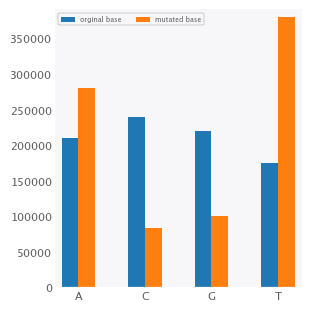

In [11]:
thresh = 1000
df_large = df[(df['max_rate'] - df['wt_rate']) > thresh].reset_index(drop=True)

plot_vals = {
    'orginal base': df_large.groupby(['orig_base']).apply(len, include_groups=False).reset_index()[0].values,
    'mutated base': df_large.groupby(['best_alt']).apply(len, include_groups=False).reset_index()[0].values
}
bases = ('A', 'C', 'G', 'T')
x = np.arange(4)
width = 0.25

multiplier = 0.5

fig, ax = plt.subplots(figsize=(3, 3), layout='constrained')

for attribute, measurement in plot_vals.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    #ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
#ax.set_ylabel('Length (mm)')
#ax.set_title('Penguin attributes by species')
ax.set_xticks(x + width, bases)
ax.legend(loc='upper left', ncols=3)

We can clearly see that most mutations are towards a `T`, followed by an `A`, which makes sense since those are the important letters in the -10 region of the promoter. Interestingly, we nearly never see a mutation towards a `C`.

Next, we look at the genomic position of these mutations.

In [12]:
bin_edges = np.arange(np.max((df['window_start'].values + df['pos_in_window'].values)), step=1000)
bins = np.zeros(len(bin_edges)-1)

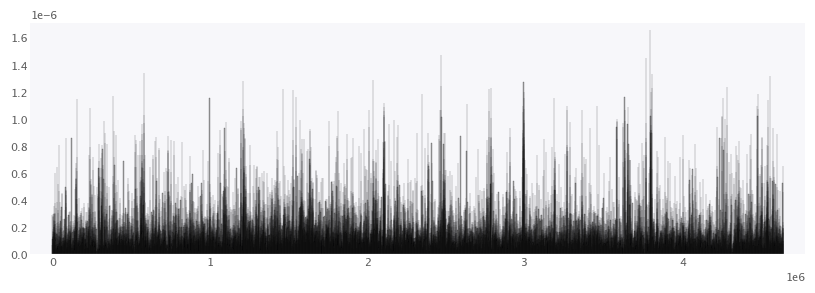

In [13]:
fig, ax = plt.subplots(figsize=(10, 3))

data = df['window_start'].values + df['pos_in_window'].values
count, bins, ignored = ax.hist(data, bins=10000, density=True, alpha=0.6, color='gray', edgecolor='black')


Get locations of all genes.

In [14]:
# Create a database from the GFF file (one-time)
gff_fn = "../../data/metadata/genomic.gff"
db = gffutils.create_db(gff_fn, dbfn='ecoli.db', force=True, keep_order=True, merge_strategy='merge', sort_attribute_values=True)

# Query genes
genes = list(db.features_of_type('gene'))
rows = []
for gene in genes:
    rows.append({
        'gene_id': gene.id,
        'gene_name': gene.attributes.get('gene', [None])[0],
        'locus_tag': gene.attributes.get('locus_tag', [None])[0],
        'start': gene.start,
        'end': gene.end,
        'strand': gene.strand,
        'chrom': gene.chrom
    })

df_genes = pd.DataFrame(rows)
print(df_genes.head())


      gene_id gene_name locus_tag  start   end strand        chrom
0  gene-b0001      thrL     b0001    190   255      +  NC_000913.3
1  gene-b0002      thrA     b0002    337  2799      +  NC_000913.3
2  gene-b0003      thrB     b0003   2801  3733      +  NC_000913.3
3  gene-b0004      thrC     b0004   3734  5020      +  NC_000913.3
4  gene-b0005      yaaX     b0005   5234  5530      +  NC_000913.3


In [15]:
df_genes[df_genes['gene_name'] ==  'thiQ']

,gene_id,gene_name,locus_tag,start,end,strand,chrom
66,gene-b0066,thiQ,b0066,72229,72927,-,NC_000913.3


In [88]:
with open('../../data/metadata/transcriptionUnit.bson','rb') as f:
    data = bson.decode_all(f.read())
    
df_TUs = pd.DataFrame(data).dropna(subset=['name']).sort_values('leftEndPosition')
print(len(df_TUs))
df_TUs.head()

11507


,_id,chromosome,datasetIds,genes,leftEndPosition,length,name,phantom,pseudo,rightEndPosition,strand,temporalId,termType
5095,ECOLITU000005095,NC_000913.3,[RHTECOLITUD02722],"[{'_id': 'RDBECOLIGNC01250', 'bnumber': 'b0001...",114,4944,thrL-thrA-thrB-thrC,0,0,5057,+,"[TUS_TU0003,114,5057,+]",TTS
5096,ECOLITU000005096,NC_000913.3,[RHTECOLITUD02722],"[{'_id': 'RDBECOLIGNC01250', 'bnumber': 'b0001...",114,5371,thrL-thrA-thrB-thrC,0,0,5484,+,"[TUS_TU0003,114,5484,+]",TTS
0,ECOLITU000000000,NC_000913.3,[RHTECOLITUD02720],"[{'_id': 'RDBECOLIGNC01250', 'bnumber': 'b0001...",147,162,thrL,0,0,308,+,"[TUS_TU0001,147,308,+]",TTS
7661,ECOLITU000007661,NC_000913.3,[RHTECOLITUD02723],"[{'_id': 'RDBECOLIGNC01250', 'bnumber': 'b0001...",147,3824,thrL-thrA-thrB,0,0,3970,+,"[TUS_TU0004,147,3970,+]",long
5097,ECOLITU000005097,NC_000913.3,[RHTECOLITUD02722],"[{'_id': 'RDBECOLIGNC01250', 'bnumber': 'b0001...",147,4911,thrL-thrA-thrB-thrC,0,0,5057,+,"[TUS_TU0003,147,5057,+]",TTS


In [89]:


def get_sequence(pos, strand='+', up=0, down=0):
    if strand == '+':
        return str(record.seq[pos-58-up:pos+20+down])
    elif strand == '-':
        return str(record.seq[pos-20-down:pos+58+up].reverse_complement())
    

def get_promoter(row, up=0, down=0):
    strand = row['strand']
    if strand == '+':
        pos = row['leftEndPosition']
    elif strand == '-':
        pos = row['rightEndPosition']

    seq = get_sequence(pos=pos, strand=strand, up=up, down=down)
    return seq, pos, strand

def compute_tx_rate(row, up=0, down=0):
    seq, pos, strand = get_promoter(row=row, up=up, down=down)
    p = regseq2.promoter_calculator.Promoter_Calculator()
    p.run(seq)
    output = p.output()
    tsses = [(output['Forward_Predictions_per_TSS'][key]['TSS'], output['Forward_Predictions_per_TSS'][key]['Tx_rate']) for key in output['Forward_Predictions_per_TSS']]
    max_ind = np.argmax([x[1] for x in tsses])
    if strand == '+':
        tss = pos - (58 + up -[x[0] for x in tsses][max_ind])
    elif strand == '-':
        tss = pos + (58 + up -[x[0] for x in tsses][max_ind])
    return tss, [x[1] for x in tsses][max_ind]

In [90]:
TUs = []
tsses = []
tx_rates = []

for ind, row in df_TUs.iterrows():
    TU = row['name']
    tss, tx_rate = compute_tx_rate(row, up=5, down=5)
    TUs.append(TU)
    tsses.append(tss)
    tx_rates.append(tx_rate)

df_TU_rates = pd.DataFrame(data={'name': TUs, 'tss': tsses, 'wt_TU_tx_rate': tx_rates}).drop_duplicates(keep=False)

In [91]:
display(df_TU_rates[['dicC' in x for x in df_TU_rates['name']]])

,name,tss,wt_TU_tx_rate
4047,ydfW-ydfX-dicC,1647875,8595.621595


In [92]:
display(df_TUs[['dicC' in x for x in df_TUs['name']]])

,_id,chromosome,datasetIds,genes,leftEndPosition,length,name,phantom,pseudo,rightEndPosition,strand,temporalId,termType
1081,ECOLITU000001081,NC_000913.3,[RHTECOLITUD02720],"[{'_id': 'RDBECOLIGNC00222', 'bnumber': 'b1569...",1646747,1129,ydfW-ydfX-dicC,0,0,1647875,-,"[TUS_TU0001,1646747,1647875,-]",TTS


In [93]:
df_TUs = df_TUs.merge(df_TU_rates, on='name')

Check with of the de novo promoters are outside of coding regions.

In [94]:
_df = []


for strand in ['+', '-']:
    temp_df = df[(df['strand'] == strand)]
    starts = df_genes[df_genes['strand'] == strand]['start'].values
    ends = df_genes[df_genes['strand'] == strand]['end'].values
    if strand == '+':
        temp_df['TSS_abs'] = temp_df['window_start'].values + temp_df['TSS'].values
        temp_df['mutation_pos'] = (temp_df['window_start'].values + temp_df['pos_in_window'].values).astype(np.int64)
    else:
        temp_df['TSS_abs'] = temp_df['window_start'].values - temp_df['TSS'].values
        temp_df['mutation_pos'] = (temp_df['window_start'].values - temp_df['pos_in_window'].values).astype(np.int64)

    #temp_df = temp_df[(temp_df['pos'] < 100_000)]
    @njit
    def in_any_interval(pos_array, starts, ends):
        result = np.zeros(pos_array.shape[0], dtype=np.bool_)
        for i in range(pos_array.shape[0]):
            for j in range(starts.shape[0]):
                if starts[j] <= pos_array[i] <= ends[j]:
                    result[i] = True
                    break
        return result

    in_genes_unfiltered = in_any_interval(temp_df['mutation_pos'].values, starts, ends)

    temp_df = temp_df[~in_genes_unfiltered]
    
    
    # Find next gene
    names = df_genes[df_genes['strand'] == strand]['gene_name'].values
    if strand == '+':
        starts = df_genes[df_genes['strand'] == strand]['start'].values
    else:
        starts = df_genes[df_genes['strand'] == strand]['end'].values

    idx = np.searchsorted(starts, temp_df['mutation_pos'].values, side='right')
    if strand == '-':
        idx -= 1

    next_genes = np.empty(len(temp_df['mutation_pos'].values), dtype=object)
    mask_valid = (idx < len(starts)) & (idx >= 0)

    next_genes[mask_valid] = names[idx[mask_valid]]
    next_genes[~mask_valid] = None

    temp_df['next_gene'] = next_genes

    # Find next TU
    if strand == '+':
        df_TUs = df_TUs.sort_values('leftEndPosition')
        starts = df_TUs[df_TUs['strand'] == strand]['leftEndPosition'].values
    else:
        df_TUs = df_TUs.sort_values('rightEndPosition')
        starts =  df_TUs[df_TUs['strand'] == strand]['rightEndPosition'].values

        
    names = df_TUs[df_TUs['strand'] == strand]['name'].values
    wt_rate = df_TUs[df_TUs['strand'] == strand]['wt_TU_tx_rate'].values
    found_tss = df_TUs[df_TUs['strand'] == strand]['tss'].values

    idx = np.searchsorted(starts, temp_df['mutation_pos'].values, side='right')

    next_TU = np.empty(len(temp_df['mutation_pos'].values), dtype=object)
    next_start = np.empty(len(temp_df['mutation_pos'].values), dtype=object)
    wt_rate_filt = np.empty(len(temp_df['mutation_pos'].values), dtype=object)
    next_found_tss = np.empty(len(temp_df['mutation_pos'].values), dtype=object)

    if strand == '-':
        idx -= 1
    
    mask_valid = (idx < len(starts)) & (idx >= 0)

    next_TU[mask_valid] = names[idx[mask_valid]]
    next_TU[~mask_valid] = None

    next_start[mask_valid] = starts[idx[mask_valid]]
    next_start[~mask_valid] = None

    wt_rate_filt[mask_valid] = wt_rate[idx[mask_valid]]
    wt_rate_filt[~mask_valid] = None

    next_found_tss[mask_valid] = found_tss[idx[mask_valid]]
    next_found_tss[~mask_valid] = None


    temp_df['next_TU'] = next_TU
    temp_df['TU_start'] = next_start
    temp_df['wt_TU_tx_rate'] = wt_rate_filt
    temp_df['found_tss'] = next_found_tss
    _df.append(temp_df)

df_nc = pd.concat(_df).sort_values('TSS_abs').reset_index(drop=True)

df_nc.drop('window_start', axis=1, inplace=True)
df_nc.drop('pos_in_window', axis=1, inplace=True)
display(df_nc.head())
display(df_nc.tail())

,orig_base,best_alt,max_rate,wt_rate,TSS,strand,TSS_abs,mutation_pos,next_gene,next_TU,TU_start,wt_TU_tx_rate,found_tss
0,A,C,1094.282357,1094.20796,61,-,21,38,None,None,None,None,None
1,A,T,1094.349318,1094.20796,61,-,21,46,None,None,None,None,None
2,T,C,1094.396937,1094.20796,61,-,21,45,None,None,None,None,None
3,T,A,1094.292773,1094.20796,61,-,21,48,None,None,None,None,None
4,T,G,1095.404637,1094.20796,61,-,21,51,None,None,None,None,None


,orig_base,best_alt,max_rate,wt_rate,TSS,strand,TSS_abs,mutation_pos,next_gene,next_TU,TU_start,wt_TU_tx_rate,found_tss
11611258,T,A,1141.062310,1115.314444,61,+,4641627,4641636,None,None,None,None,None
11611259,C,G,1154.514319,1115.314444,61,+,4641627,4641635,None,None,None,None,None
11611260,A,G,1164.527699,1115.314444,61,+,4641627,4641631,None,None,None,None,None
11611261,A,T,1137.548433,1115.314444,61,+,4641627,4641638,None,None,None,None,None
11611262,T,A,1195.091949,1115.314444,60,+,4641627,4641637,None,None,None,None,None


Let's find the gene that is leading up to each gene.

In [96]:
df_nc['in_range'] = np.abs(df_nc['TSS_abs'] - df_nc['found_tss']) < 150
df_nc[df_nc['in_range']].dropna(subset='next_TU').groupby('next_TU').apply(len, include_groups=False).reset_index().sort_values(0, ascending=False)

,next_TU,0
337,galP,3313
813,pykF,3165
847,rfaD-waaF-waaC,3159
450,htrL,3024
256,elfA,2979
...,...,...
701,osmF,2
173,cvpA-dedD-folC-accD,2
925,rraA-menA-hslU-hslV-ftsN-cytR,2
241,dsbC-xerD,1


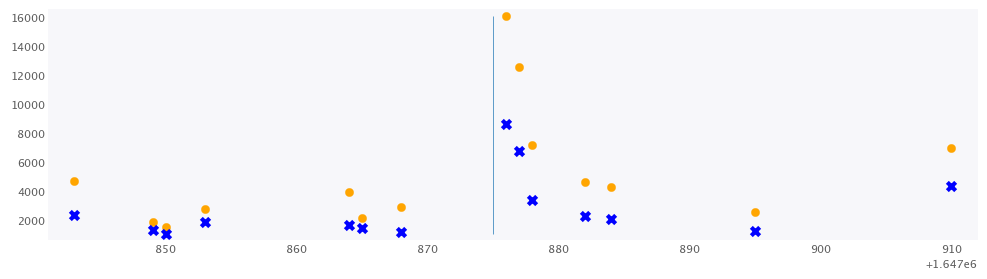

In [98]:
df_xylA = df_nc[(df_nc['next_gene'] == 'dicC') & df_nc['in_range']]

n = len(df_xylA['TU_start'].unique())
fig, ax = plt.subplots(n, 1, figsize=(12, 3*n))

if n == 1:
    ax = [ax]
for i, (TU, gdf) in enumerate(df_xylA.groupby(['TU_start'])):
    ax[i].vlines([TU], ymin=np.min(df_xylA['max_rate']), ymax=np.max(df_xylA['max_rate']))
    for TSS, _gdf in gdf.groupby(['TSS_abs']):
        ax[i].scatter([TSS], [np.max(_gdf['max_rate'])], color="orange")
        ax[i].scatter([TSS], [np.max(_gdf['wt_rate'])], marker='x', lw=3, color='blue')

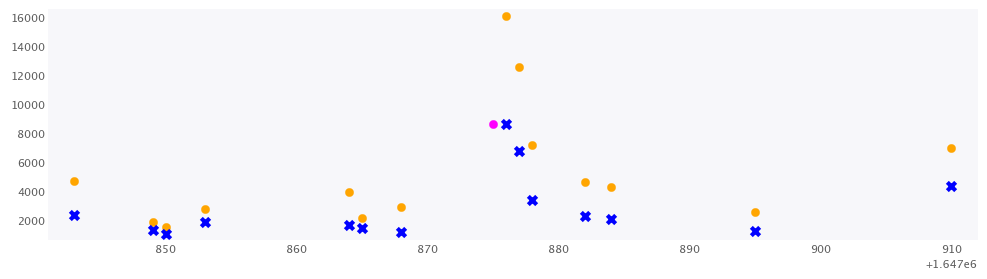

In [100]:
df_xylA = df_nc[(df_nc['next_gene'] == 'dicC') & df_nc['in_range']]

n = len(df_xylA['TU_start'].unique())
fig, ax = plt.subplots(n, 1, figsize=(12, 3*n))

if n == 1:
    ax = [ax]
for i, (TU, gdf) in enumerate(df_xylA.groupby(['found_tss'])):
    ax[i].scatter([TU], gdf['wt_TU_tx_rate'].values[0], color='magenta')
    for TSS, _gdf in gdf.groupby(['TSS_abs']):
        ax[i].scatter([TSS], [np.max(_gdf['max_rate'])], color="orange")
        ax[i].scatter([TSS], [np.max(_gdf['wt_rate'])], marker='x', lw=3, color='blue')

In [23]:
df_xylA.sort_values('max_rate', ascending=False)

,orig_base,best_alt,max_rate,wt_rate,TSS,strand,TSS_abs,mutation_pos,next_gene,next_TU,TU_start,in_range
4212483,T,A,16071.605812,8595.621595,61,-,1647876,1647885,dicC,ydfW-ydfX-dicC,1647875,True
4212481,C,A,15716.337185,8595.621595,61,-,1647876,1647886,dicC,ydfW-ydfX-dicC,1647875,True
4212426,T,C,15059.881157,8595.621595,61,-,1647876,1647882,dicC,ydfW-ydfX-dicC,1647875,True
4212538,T,A,12541.987551,6707.866053,61,-,1647877,1647885,dicC,ydfW-ydfX-dicC,1647875,True
4212491,T,A,12298.499872,8595.621595,61,-,1647876,1647907,dicC,ydfW-ydfX-dicC,1647875,True
...,...,...,...,...,...,...,...,...,...,...,...,...
4211859,T,A,1030.430366,1021.945222,61,-,1647850,1647900,dicC,ydfW-ydfX-dicC,1647875,True
4211861,G,A,1028.824244,1021.945222,61,-,1647850,1647904,dicC,ydfW-ydfX-dicC,1647875,True
4211833,G,A,1022.146736,1021.945222,61,-,1647850,1647879,dicC,ydfW-ydfX-dicC,1647875,True
4211851,T,G,1022.135617,1021.945222,61,-,1647850,1647878,dicC,ydfW-ydfX-dicC,1647875,True


In [24]:
df_nc[df_nc['next_gene']=='araA-ara']['TU_start'].unique()

array([], dtype=object)

Allow to filter for mutations that are close to the initital promoter.

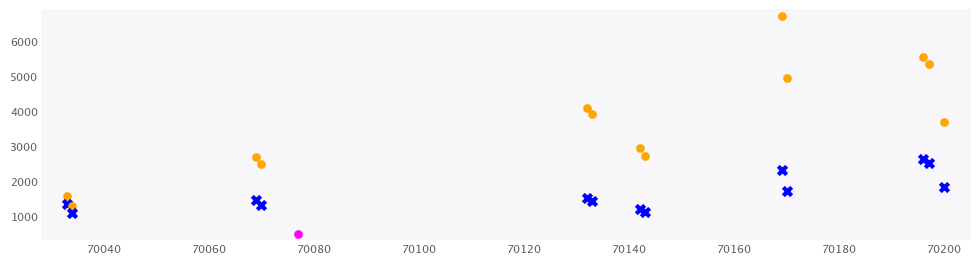

In [101]:
df_xylA = df_nc[(df_nc['next_gene'] == 'araB') & df_nc['in_range']]

n = len(df_xylA['TU_start'].unique())
fig, ax = plt.subplots(n, 1, figsize=(12, 3*n))

if n == 1:
    ax = [ax]
for i, (TU, gdf) in enumerate(df_xylA.groupby(['found_tss'])):
    ax[i].scatter([TU], gdf['wt_TU_tx_rate'].values[0], color='magenta')
    for TSS, _gdf in gdf.groupby(['TSS_abs']):
        ax[i].scatter([TSS], [np.max(_gdf['max_rate'])], color="orange")
        ax[i].scatter([TSS], [np.max(_gdf['wt_rate'])], marker='x', lw=3, color='blue')

In [26]:
df_xylA.sort_values('max_rate', ascending=False)

,orig_base,best_alt,max_rate,wt_rate,TSS,strand,TSS_abs,mutation_pos,next_gene,next_TU,TU_start,in_range
130713,G,T,6718.832464,2315.969254,61,-,70169,70182,araB,araA-araB,70077,True
130944,A,C,5546.602538,2625.750598,61,-,70196,70228,araB,araA-araB,70077,True
131081,A,C,5338.480888,2527.226223,61,-,70197,70228,araB,araA-araB,70077,True
130969,A,T,5055.663842,2625.750598,61,-,70196,70231,araB,araA-araB,70077,True
130683,G,A,5022.175356,2315.969254,61,-,70169,70200,araB,araA-araB,70077,True
...,...,...,...,...,...,...,...,...,...,...,...,...
130479,A,C,1107.509500,1107.303203,61,-,70143,70164,araB,araA-araB,70077,True
130462,T,C,1107.494441,1107.303203,61,-,70143,70166,araB,araA-araB,70077,True
130461,C,A,1107.449263,1107.303203,61,-,70143,70165,araB,araA-araB,70077,True
130493,T,A,1107.446252,1107.303203,61,-,70143,70160,araB,araA-araB,70077,True


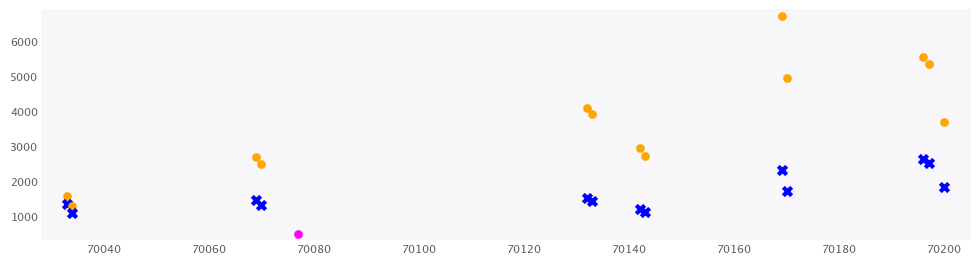

In [102]:
df_araB = df_nc[(df_nc['next_TU'] == 'hokC-mokC')]

n = len(df_xylA['TU_start'].unique())
fig, ax = plt.subplots(n, 1, figsize=(12, 3*n))

if n == 1:
    ax = [ax]
for i, (TU, gdf) in enumerate(df_xylA.groupby(['found_tss'])):
    ax[i].scatter([TU], gdf['wt_TU_tx_rate'].values[0], color='magenta')
    for TSS, _gdf in gdf.groupby(['TSS_abs']):
        ax[i].scatter([TSS], [np.max(_gdf['max_rate'])], color="orange")
        ax[i].scatter([TSS], [np.max(_gdf['wt_rate'])], marker='x', lw=3, color='blue')

In [28]:
df_xylA = df_nc[(df_nc['next_gene'] == 'dicC')]
df_xylA

,orig_base,best_alt,max_rate,wt_rate,TSS,strand,TSS_abs,mutation_pos,next_gene,next_TU,TU_start,in_range
4211354,T,A,1116.525143,1107.331046,61,-,1647796,1647855,dicC,hokD-relE-relB,1646235,False
4211355,A,T,1116.525143,1107.331046,61,-,1647796,1647852,dicC,hokD-relE-relB,1646235,False
4211356,T,A,1116.525143,1107.331046,61,-,1647796,1647857,dicC,hokD-relE-relB,1646235,False
4211357,T,A,1065.390094,1056.617072,61,-,1647798,1647857,dicC,hokD-relE-relB,1646235,False
4211358,A,T,1065.390094,1056.617072,61,-,1647798,1647852,dicC,hokD-relE-relB,1646235,False
...,...,...,...,...,...,...,...,...,...,...,...,...
4234577,A,T,1352.640747,1326.202665,61,-,1652720,1652707,dicC,ydfW-ydfX-dicC,1647875,False
4234578,A,T,1352.640747,1326.202665,61,-,1652720,1652715,dicC,ydfW-ydfX-dicC,1647875,False
4234579,A,G,1347.643774,1326.202665,61,-,1652720,1652710,dicC,ydfW-ydfX-dicC,1647875,False
4234580,T,A,1421.064827,1326.202665,61,-,1652720,1652708,dicC,ydfW-ydfX-dicC,1647875,False


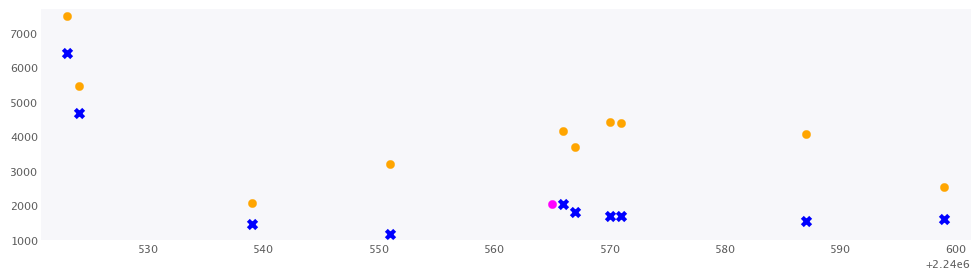

In [103]:
df_xylA = df_nc[(df_nc['next_gene'] == 'mglB') & df_nc['in_range']]

n = len(df_xylA['TU_start'].unique())
fig, ax = plt.subplots(n, 1, figsize=(12, 3*n))

if n == 1:
    ax = [ax]
for i, (TU, gdf) in enumerate(df_xylA.groupby(['found_tss'])):
    ax[i].scatter([TU], gdf['wt_TU_tx_rate'].values[0], color='magenta')
    for TSS, _gdf in gdf.groupby(['TSS_abs']):
        ax[i].scatter([TSS], [np.max(_gdf['max_rate'])], color="orange")
        ax[i].scatter([TSS], [np.max(_gdf['wt_rate'])], marker='x', lw=3, color='blue')

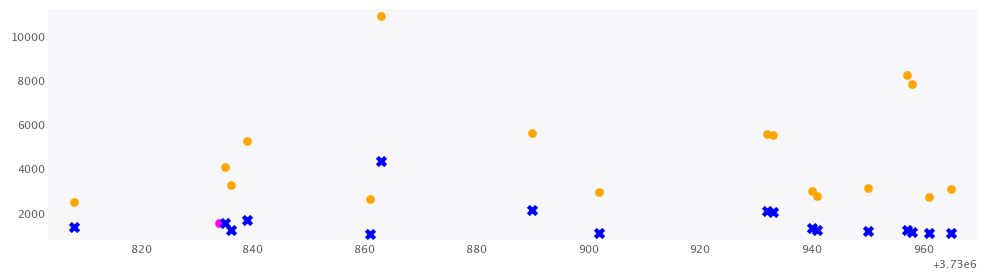

In [104]:
df_xylA = df_nc[(df_nc['next_gene'] == 'xylA') & df_nc['in_range']]


n = len(df_xylA['TU_start'].unique())
fig, ax = plt.subplots(n, 1, figsize=(12, 3*n))

if n == 1:
    ax = [ax]
for i, (TU, gdf) in enumerate(df_xylA.groupby(['found_tss'])):
    ax[i].scatter([TU], gdf['wt_TU_tx_rate'].values[0], color='magenta')
    for TSS, _gdf in gdf.groupby(['TSS_abs']):
        ax[i].scatter([TSS], [np.max(_gdf['max_rate'])], color="orange")
        ax[i].scatter([TSS], [np.max(_gdf['wt_rate'])], marker='x', lw=3, color='blue')

## Get tx rate for each TU

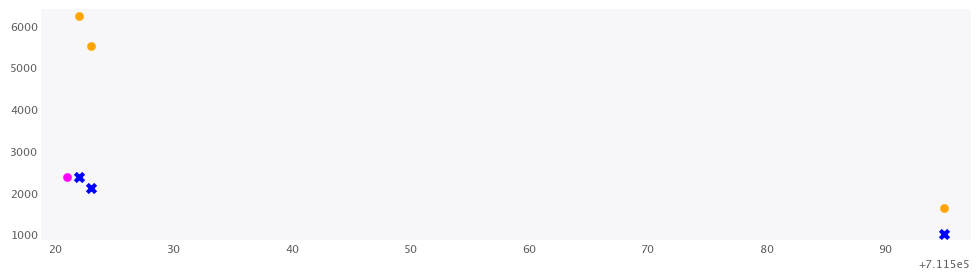

In [106]:
df_xylA = df_nc[(df_nc['next_gene'] == 'fldA') & df_nc['in_range']]


n = len(df_xylA['TU_start'].unique())
fig, ax = plt.subplots(n, 1, figsize=(12, 3*n))

if n == 1:
    ax = [ax]
for i, (TU, gdf) in enumerate(df_xylA.groupby(['found_tss'])):
    ax[i].scatter([TU], gdf['wt_TU_tx_rate'].values[0], color='magenta')
    for TSS, _gdf in gdf.groupby(['TSS_abs']):
        ax[i].scatter([TSS], [np.max(_gdf['max_rate'])], color="orange")
        ax[i].scatter([TSS], [np.max(_gdf['wt_rate'])], marker='x', lw=3, color='blue')

In [31]:
df_TUs.head()

,_id,chromosome,datasetIds,genes,leftEndPosition,length,name,phantom,pseudo,rightEndPosition,strand,temporalId,termType
0,ECOLITU000000000,NC_000913.3,[RHTECOLITUD02720],"[{'_id': 'RDBECOLIGNC01250', 'bnumber': 'b0001...",147,162,thrL,0,0,308,+,"[TUS_TU0001,147,308,+]",TTS
3179,ECOLITU000003179,NC_000913.3,[RHTECOLITUD02721],"[{'_id': 'RDBECOLIGNC01250', 'bnumber': 'b0001...",147,162,thrL,0,0,308,+,"[TUS_TU0002,147,308,+]",TTS
7661,ECOLITU000007661,NC_000913.3,[RHTECOLITUD02723],"[{'_id': 'RDBECOLIGNC01250', 'bnumber': 'b0001...",147,3824,thrL-thrA-thrB,0,0,3970,+,"[TUS_TU0004,147,3970,+]",long
10119,ECOLITU000010127,NC_000913.3,[RHTECOLITUD02724],"[{'_id': 'RDBECOLIGNC00987', 'bnumber': 'b0003...",2580,2290,thrB,0,0,4869,+,"[TUS_TU0005,2580,4869,+]",long
5095,ECOLITU000005095,NC_000913.3,[RHTECOLITUD02722],"[{'_id': 'RDBECOLIGNC01250', 'bnumber': 'b0001...",114,4944,thrL-thrA-thrB-thrC,0,0,5057,+,"[TUS_TU0003,114,5057,+]",TTS


In [34]:
df_TS_rates.head()

,TU,tss,wt_TU_tx_rate
0,thrL,149,2344.335655
1,thrL,149,2344.335655
2,thrL-thrA-thrB,149,2344.335655
3,thrB,2583,725.117470
4,thrL-thrA-thrB-thrC,115,1827.303298


,TU,tss,wt_TU_tx_rate
4047,ydfW-ydfX-dicC,1647885,8595.621595


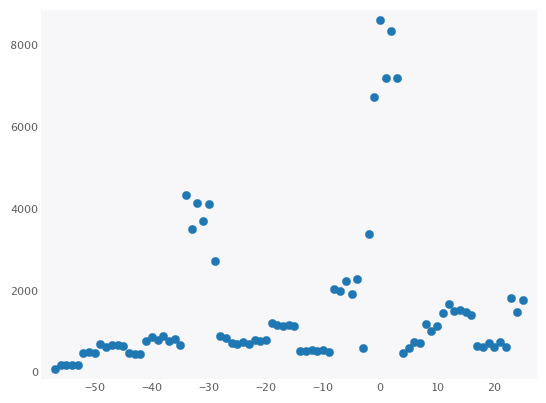

In [227]:
p = regseq2.promoter_calculator.Promoter_Calculator()
p.run(dicC_seq)
output = p.output()
x = [output['Forward_Predictions_per_TSS'][key]['TSS']-115 for key in output['Forward_Predictions_per_TSS']]
y = [output['Forward_Predictions_per_TSS'][key]['Tx_rate'] for key in output['Forward_Predictions_per_TSS']]
 
plt.scatter(x, y)

In [528]:
get_sequence(1647875, '-', up=10, down=10)

'TTGTTTCCATAGTTAGCTAATGCTAAATCGTATTGACTATGTTTTTGTTAACATCTATCTTGTTAGTTATGACTAACAATAAAGGTGTTTTAAATGCT'

'AGTTAGCTAATGCTAAATCGTATTGACTATGTTTTTGTTAACATCTATCTTGTTAGTTATGACTAACAATAAAGGTGT'

In [525]:
dicC_seq[57:57+78]

'AGTTAGCTAATGCTAAATCGTATTGACTATGTTTTTGTTAACATCTATCTTGTTAGTTATGACTAACAATAAAGGTGT'

In [268]:
p.run(dicC_seq[57-3:57+79])
output = p.output()
[output['Forward_Predictions_per_TSS'][key]['Tx_rate'] for key in output['Forward_Predictions_per_TSS']]

[407.60991978882447,
 3366.3885410174616,
 6707.866053230897,
 8595.621595466404,
 7187.674072098447]

In [269]:
[output['Forward_Predictions_per_TSS'][key]['TSS'] for key in output['Forward_Predictions_per_TSS']]

[58, 59, 60, 61, 62]

In [270]:
[len(output['Forward_Predictions_per_TSS'][key]['spacer']) for key in output['Forward_Predictions_per_TSS']]

[15, 16, 17, 17, 17]

In [414]:
df_nc['relative_change'] = df_nc['max_rate'] / df_nc['wt_rate']
df_nc['absolute_change'] = df_nc['max_rate'] - df_nc['wt_rate']

In [501]:
idx = df_nc[df_nc['in_range']].groupby('next_gene')['relative_change'].idxmax()

# Select the rows corresponding to these indices
result = df_nc[df_nc['in_range']].loc[idx]

In [502]:
result.sort_values('absolute_change', ascending=False)

,orig_base,best_alt,max_rate,wt_rate,TSS,strand,pos,next_gene,next_TU,TU_start,in_range,relative_change,absolute_change
11113902,G,A,53847.625481,11497.584283,4474080,-,4474089,bdcA,yjgH-bdcA,4474077,True,4.683386,42350.041198
4821855,T,A,22405.669587,3213.791476,1877661,+,1877653,dgcP,dgcP-yoaK-yoaJ,1877667,True,6.971725,19191.878111
10304869,T,A,22342.187765,3204.685864,4112241,-,4112250,yiiQ,tpiA-yiiQ,4112237,True,6.971725,19137.501901
2822370,C,T,25558.720009,9410.058492,1202187,-,1202198,ymfJ,ymfJ,1202184,True,2.716106,16148.661517
1048783,C,T,20525.393286,5037.796035,461391,+,461387,hupB,hupB-ppiD,461394,True,4.074280,15487.597251
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8180124,T,G,1232.430484,1192.054800,3212850,+,3212853,rpoD,rpoD,3212855,True,1.033871,40.375684
1985866,T,G,1067.424324,1032.454411,838540,-,838527,ybiI,ybiJ-ybiI,838483,True,1.033871,34.969914
10428522,A,T,1166.928876,1142.677110,4178916,+,4178877,rplA,rplJ-rplL,4178908,True,1.021224,24.251766
206933,G,A,1406.861457,1406.584098,111830,-,111853,yacG,b0100,111828,True,1.000197,0.277360


## By regulatory architecture

In [503]:
with open('../../data/metadata/geneDatamart.bson','rb') as f:
    data = bson.decode_all(f.read())

df_reg = pd.DataFrame(data).dropna(subset='regulation')
df_reg.head()

,_id,allCitations,gene,organism,products,regulation
0,RDBECOLIGNC00001,"[{'evidence': {'_id': 'RDBECOLIEVC00039', 'add...","{'_id': 'RDBECOLIGNC00001', 'bnumber': 'b4053'...",{'_id': 'RDBECOLIORC00001'},"[{'_id': 'RDBECOLIPDC00061', 'abbreviatedName'...","{'operon': {'_id': 'RDBECOLIOPC02704', 'arrang..."
1,RDBECOLIGNC00002,"[{'publication': {'_id': 'RDBECOLIPRC26976', '...","{'_id': 'RDBECOLIGNC00002', 'bnumber': 'b0764'...",{'_id': 'RDBECOLIORC00001'},"[{'_id': 'RDBECOLIPDC03511', 'abbreviatedName'...","{'operon': {'_id': 'RDBECOLIOPC01815', 'arrang..."
2,RDBECOLIGNC00003,"[{'publication': {'_id': 'RDBECOLIPRC19122', '...","{'_id': 'RDBECOLIGNC00003', 'bnumber': 'b2413'...",{'_id': 'RDBECOLIORC00001'},"[{'_id': 'RDBECOLIPDC00374', 'abbreviatedName'...","{'operon': {'_id': 'RDBECOLIOPC00713', 'arrang..."
3,RDBECOLIGNC00004,"[{'publication': {'_id': 'RDBECOLIPRC01364', '...","{'_id': 'RDBECOLIGNC00004', 'bnumber': 'b3639'...",{'_id': 'RDBECOLIORC00001'},"[{'_id': 'RDBECOLIPDC00375', 'abbreviatedName'...","{'operon': {'_id': 'RDBECOLIOPC01138', 'arrang..."
4,RDBECOLIGNC00005,"[{'publication': {'_id': 'RDBECOLIPRC05659', '...","{'_id': 'RDBECOLIGNC00005', 'bnumber': 'b4123'...",{'_id': 'RDBECOLIORC00001'},"[{'_id': 'RDBECOLIPDC00310', 'abbreviatedName'...","{'operon': {'_id': 'RDBECOLIOPC03461', 'arrang..."


In [504]:
df_reg_sum = pd.DataFrame()

for i, row in df_reg.iterrows():
    gene = row['gene']['name']
    if 'regulators' in list(row['regulation'].keys()):
        regulators = row['regulation']['regulators']
        for dic in regulators:
            tf = dic['name']
            if 'function' in list(dic.keys()):
                func = dic['function']
            else:
                continue
            new_row_df = pd.DataFrame(data={'gene': [gene], 'TF': [tf], 'type': [func]})
            # Concatenate to add the new row
            df_reg_sum = pd.concat([df_reg_sum, new_row_df], ignore_index=True)

In [505]:
df_arcs = pd.DataFrame()
for gene, gdf in df_reg_sum.groupby('gene'):
    A = np.sum(gdf['type'] == 'activator')
    R = np.sum(gdf['type'] == 'repressor')

    new_row_df = pd.DataFrame(data={'gene': [gene], 'arch': [f'({A}, {R})']})
    # Concatenate to add the new row
    df_arcs = pd.concat([df_arcs, new_row_df], ignore_index=True)

In [506]:
result = result.merge(df_arcs, right_on='gene', left_on='next_gene', how='left')
result['arch'] = result['arch'].fillna('(0, 0)')

In [508]:
result.drop(columns=['gene'], inplace=True)

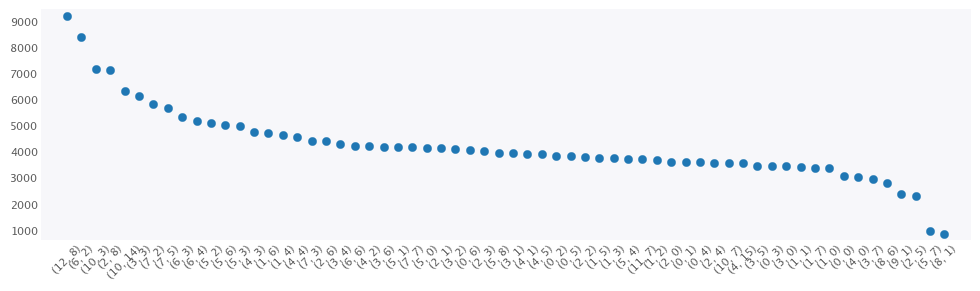

In [521]:
_df = result.groupby('arch')['absolute_change'].median().reset_index().sort_values('absolute_change', ascending=False)
fig, ax = plt.subplots(figsize=(12, 3))
ax.scatter(np.arange(len(_df)), _df['absolute_change'])
ax.set_xticks(np.arange(len(_df)), _df['arch'], rotation=45);

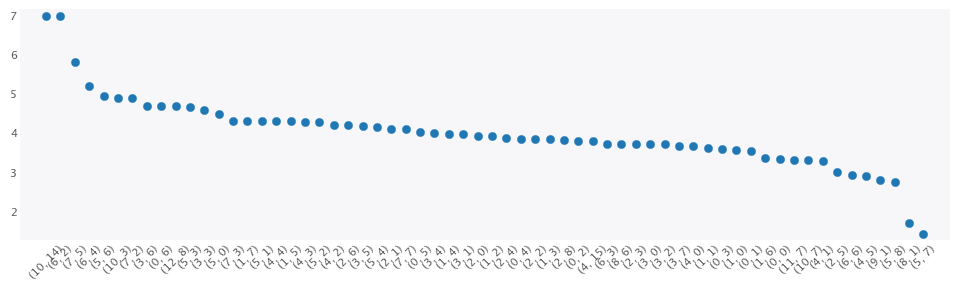

In [522]:
_df = result.groupby('arch')['relative_change'].mean().reset_index().sort_values('relative_change', ascending=False)
fig, ax = plt.subplots(figsize=(12, 3))
ax.scatter(np.arange(len(_df)), _df['relative_change'])
ax.set_xticks(np.arange(len(_df)), _df['arch'], rotation=45);

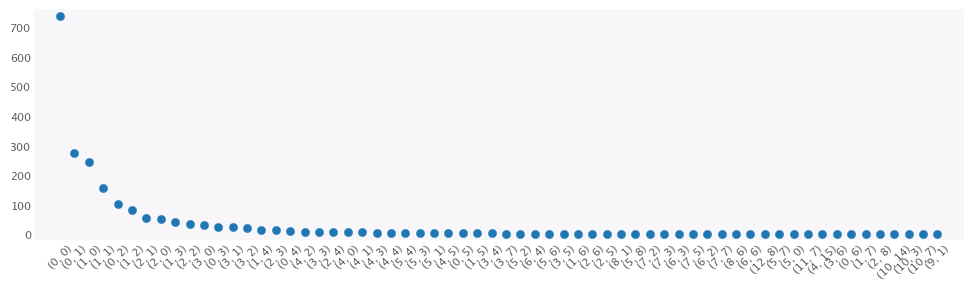

In [ ]:
_df = e.groupby('arch').apply(len, include_groups=False).reset_index().sort_values(0, ascending=False)
fig, ax = plt.subplots(figsize=(12, 3))
ax.scatter(np.arange(len(_df)), _df[0])
ax.set_xticks(np.arange(len(_df)), _df['arch'], rotation=45);

In [ ]:
np.sum()